Train: 685, Val: 136, Test: 34
cuda
Epoch 1/5 | Train: 0.1206 | Val: 0.1032
Epoch 2/5 | Train: 0.0701 | Val: 0.0635
Epoch 3/5 | Train: 0.0575 | Val: 0.0536
Epoch 4/5 | Train: 0.0510 | Val: 0.0485
Epoch 5/5 | Train: 0.0465 | Val: 0.0434
Test Loss: 0.0509


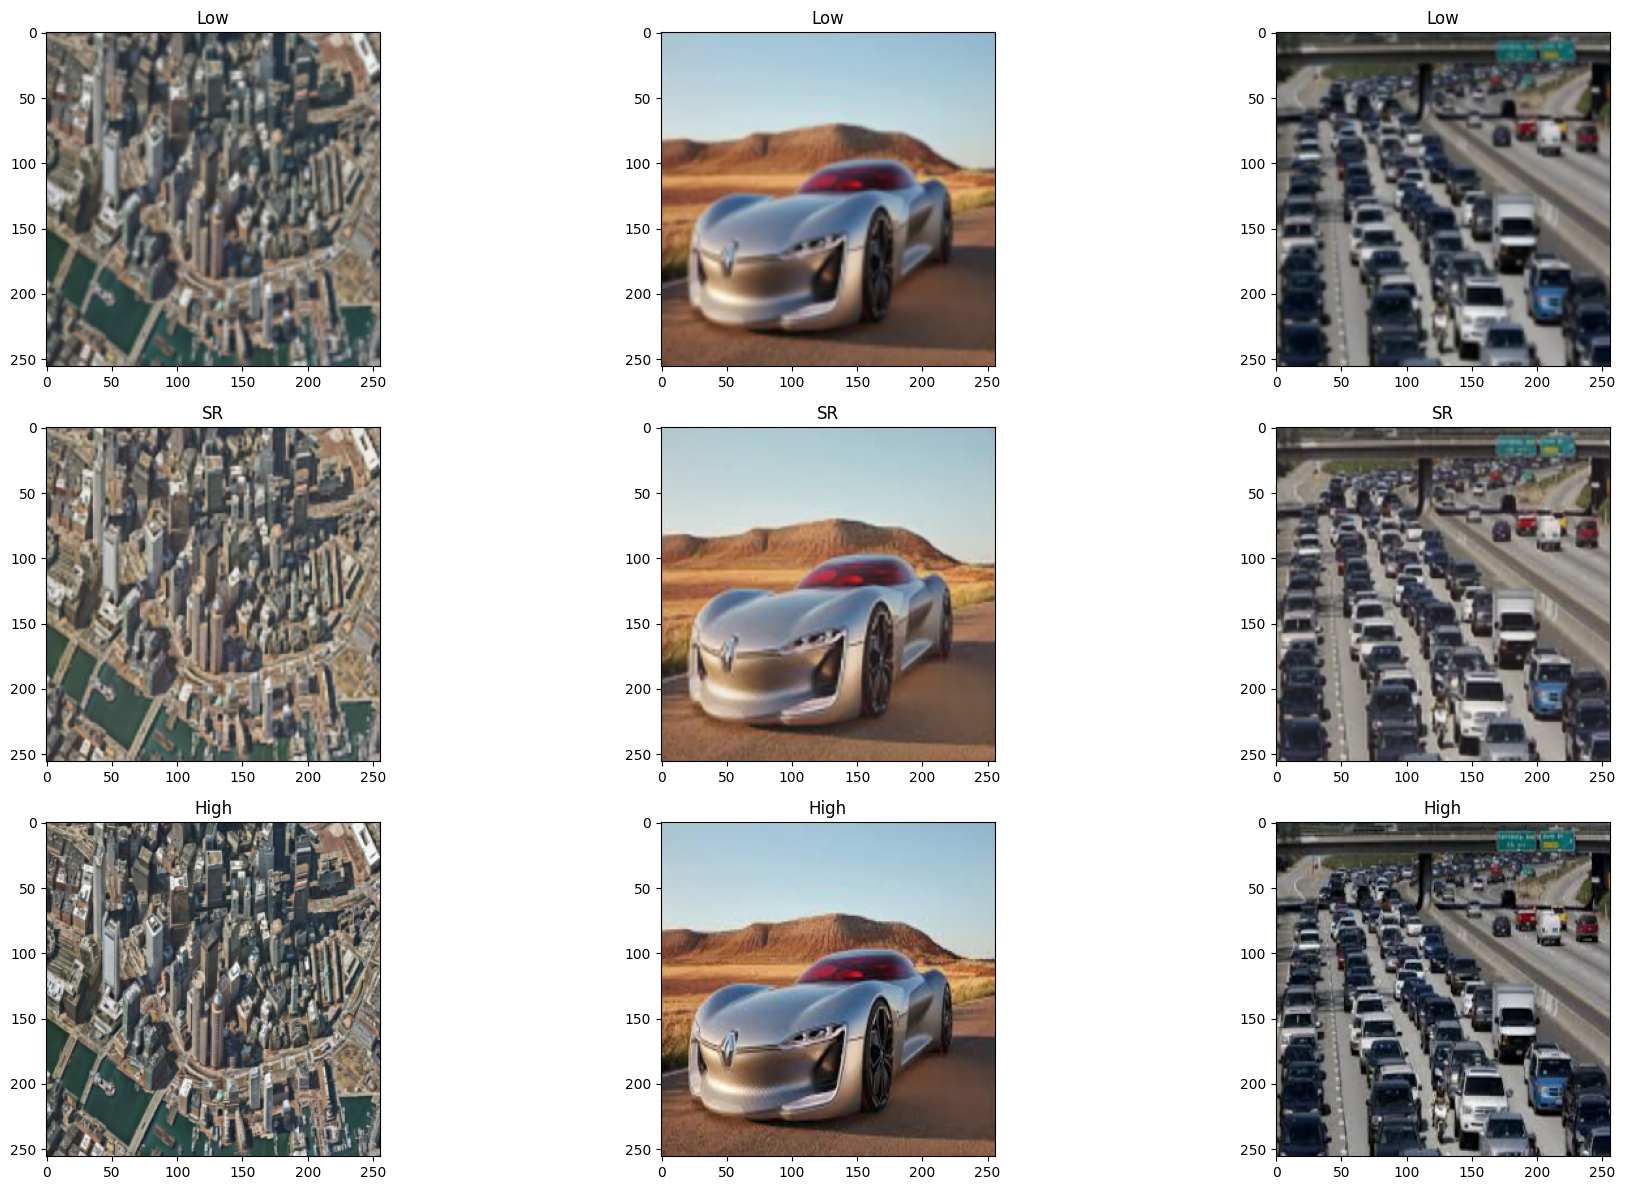

PermissionError: [Errno 13] Permission denied: '/model'

In [ ]:
# =========================
# 1. IMPORTS
# =========================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
from torchvision.models import vgg19, VGG19_Weights
from PIL import Image
import matplotlib.pyplot as plt


dataset_path = "dataset_sr"

# =========================
# 3. DATASET CLASS
# =========================
class SRDataset(Dataset):
    def __init__(self, root, mode="train", transform=None):
        self.hr_path = os.path.join(root, mode, "high_res")
        self.lr_path = os.path.join(root, mode, "low_res")

        self.hr_imgs = sorted(os.listdir(self.hr_path))
        self.lr_imgs = sorted(os.listdir(self.lr_path))

        self.transform = transform

    def __len__(self):
        return len(self.hr_imgs)

    def __getitem__(self, idx):
        hr = Image.open(os.path.join(self.hr_path, self.hr_imgs[idx])).convert("RGB")
        lr = Image.open(os.path.join(self.lr_path, self.lr_imgs[idx])).convert("RGB")

        if self.transform:
            hr = self.transform(hr)
            lr = self.transform(lr)

        return lr, hr

# =========================
# 4. TRANSFORMS
# =========================
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

train_dataset = SRDataset(dataset_path, "train", transform)
val_dataset_full = SRDataset(dataset_path, "val", transform)

# =========================
# 5. SPLIT VAL → VAL + TEST
# =========================
val_size = int(0.8 * len(val_dataset_full))
test_size = len(val_dataset_full) - val_size

val_dataset, test_dataset = random_split(
    val_dataset_full,
    [val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

print(f"Images in Train: {len(train_dataset)}")
print(f"Images in Validation: {len(val_dataset)}")
print(f"Images in Test: {len(test_dataset)}")

# =========================
# 6. UNET MODEL
# =========================
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, 1, 1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, 1, 1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.net(x)

class UNET(nn.Module):
    def __init__(self):
        super().__init__()
        features = [64,128,256,512]

        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)

        in_c = 3
        for f in features:
            self.downs.append(DoubleConv(in_c, f))
            in_c = f

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f*2, f, 2, 2))
            self.ups.append(DoubleConv(f*2, f))

        self.final = nn.Conv2d(features[0], 3, 1)

    def forward(self, x):
        skips = []

        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x)
            skip = skips[i//2]

            if x.shape != skip.shape:
                x = torch.nn.functional.interpolate(x, size=skip.shape[2:])

            x = self.ups[i+1](torch.cat([skip, x], dim=1))

        return torch.sigmoid(self.final(x))

# =========================
# 7. VGG PERCEPTUAL LOSS
# =========================
class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = vgg19(weights=VGG19_Weights.DEFAULT).features[:16].eval()

        for p in vgg.parameters():
            p.requires_grad = False

        self.vgg = vgg
        self.loss = nn.MSELoss()

        self.mean = torch.tensor([0.485,0.456,0.406]).view(1,3,1,1)
        self.std = torch.tensor([0.229,0.224,0.225]).view(1,3,1,1)

    def forward(self, x, y):
        x = (x - self.mean.to(x.device)) / self.std.to(x.device)
        y = (y - self.mean.to(y.device)) / self.std.to(y.device)

        return self.loss(self.vgg(x), self.vgg(y))

# =========================
# 8. TRAINING SETUP
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

model = UNET().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

mse = nn.MSELoss()
vgg_loss = VGGPerceptualLoss().to(device)

# =========================
# 9. TRAINING LOOP
# =========================
epochs = 5

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for lr_img, hr_img in train_loader:
        lr_img = lr_img.to(device)
        hr_img = hr_img.to(device)

        sr = model(lr_img)

        loss_pixel = mse(sr, hr_img)
        loss_perc = vgg_loss(sr, hr_img)
        loss = loss_pixel + 0.01 * loss_perc

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # ================= VALIDATION =================
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for lr_img, hr_img in val_loader:
            lr_img = lr_img.to(device)
            hr_img = hr_img.to(device)

            sr = model(lr_img)

            loss = mse(sr, hr_img) + 0.01 * vgg_loss(sr, hr_img)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train: {train_loss/len(train_loader):.4f} | "
          f"Val: {val_loss/len(val_loader):.4f}")

# =========================
# 10. TEST EVALUATION
# =========================
model.eval()
test_loss = 0

with torch.no_grad():
    for lr_img, hr_img in test_loader:
        lr_img = lr_img.to(device)
        hr_img = hr_img.to(device)

        sr = model(lr_img)
        loss = mse(sr, hr_img) + 0.01 * vgg_loss(sr, hr_img)
        test_loss += loss.item()

print(f"Test Loss: {test_loss/len(test_loader):.4f}")

# =========================
# 11. VISUALIZATION
# =========================
lr, hr = next(iter(val_loader))

with torch.no_grad():
    sr = model(lr.to(device)).cpu()

plt.figure(figsize=(20,12))

for i in range(3):
    plt.subplot(3,3,i+1)
    plt.imshow(lr[i].permute(1,2,0))
    plt.title("Low")

    plt.subplot(3,3,i+4)
    plt.imshow(sr[i].permute(1,2,0))
    plt.title("SR")

    plt.subplot(3,3,i+7)
    plt.imshow(hr[i].permute(1,2,0))
    plt.title("High")

plt.tight_layout()
plt.show()

# =========================
# 12. SAVE MODEL
# =========================
os.makedirs('model', exist_ok=True)
torch.save(model.state_dict(), "model/unet_sr.pth")
print("Model saved!")